# Extending Synthetic Controls with Covariates and Bayesian Structural Time Series
At their core, synthetic controls combine untreated comparison units into a weighted average to approximate what would have happened to the treated unit without the event.

While many models (e.g., Lasso-based synthetic controls or event studies) rely mainly on past outcome values, researchers can also incorporate additional covariates such as economic indicators, demographics, or platform usage. This can strengthen the model when the donor pool is large, though it risks instability if too many noisy variables are included.

Adding predictors can reduce bias but may increase variance. Placebo tests help compare whether more complex models truly outperform simpler outcome-based versions.

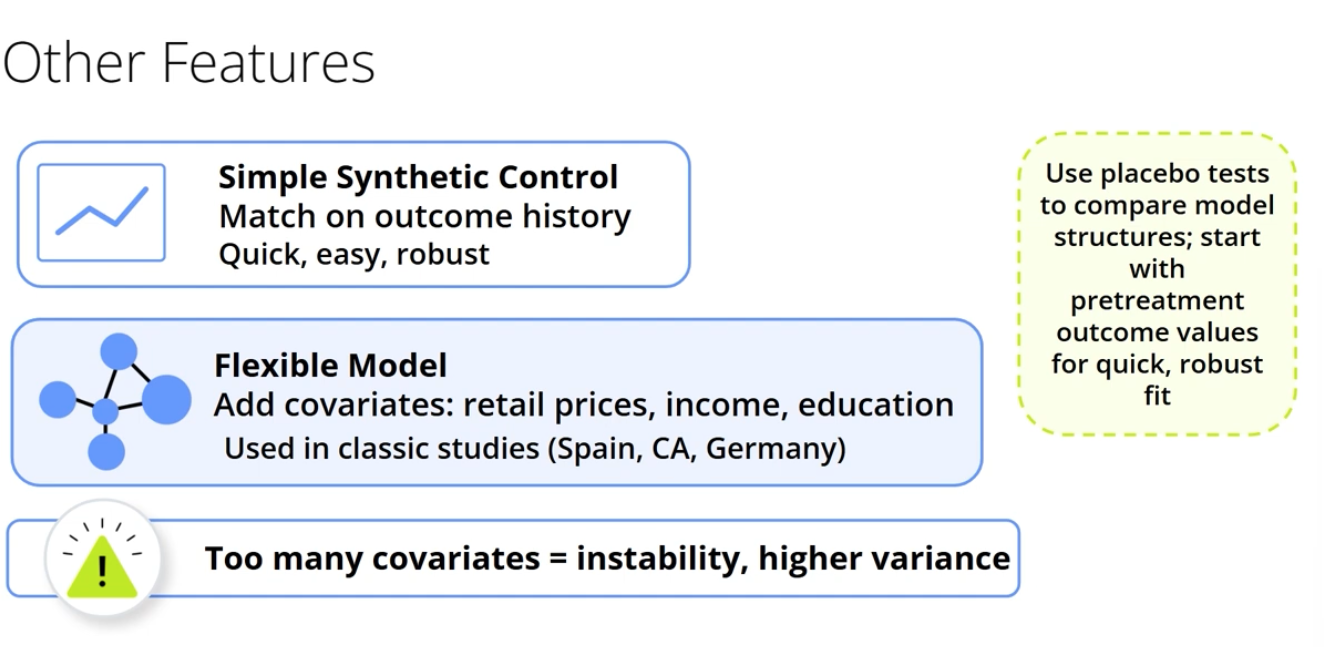

## Bayesian Structural Time Series (BSTS)
- BSTS is an influential extension of synthetic controls implemented in the CausalImpact package (originally developed at Google)
- Combines regression weights for comparison groups with time series components like trends, seasonality, and autoregressive patterns
- Allows time-varying coefficients and provides credible intervals to assess statistical significance
- Especially valuable when comparison units alone aren’t very predictive, though it can struggle if the treated unit’s time series is difficult to model

## Practical Note
BSTS via CausalImpact is currently only available in R, not Python. While this course focuses on Python, the shared R examples help you compare results, and AI coding tools can assist in adapting code across languages.

# CausalImpact (BSTS) In R

## Code Snippet 1

```
# Define the file path
file_path <- "data/synthetic_control_revenue_data.csv"

# Read the CSV file
revenue_data <- read_csv(file_path)
```

## Output 1

```
## Rows: 24 Columns: 11
## ── Column specification ─────────────────────────────────────────────────────────────
──────────────────────────────────────────────────────────────
## Delimiter: ","
## dbl (10): Region 1, Region 2, Region 3, Region 4, Region 5, Region 6, Region 7, Regi
on 8, Region 9, Region 10
## date (1): Month
##
## ℹ Use `spec()` to retrieve the full column specification for this data.
## ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
```

## Code Snippet 2

```
# Replace spaces with underscores in column names
colnames(revenue_data) <- gsub(" ", "_", colnames(revenue_data))

# Prepare the data for CausalImpact

# Extract the treated region (Region 5) and the control regions (Region 1 to Region 4, Region 6 to Region 10)
treated_region <- revenue_data$Region_5
control_regions <- revenue_data[, c("Region_1", "Region_2", "Region_3", "Region_4",
 "Region_6", "Region_7", "Region_8", "Regio
n_9", "Region_10")]

# Combine treated and control regions into a matrix
impact_data <- cbind(treated_region, control_regions)

# Define the pre-treatment and post-treatment periods
pre_period <- c(1, which(revenue_data$Month == "2024-09-01"))
post_period <- c(which(revenue_data$Month == "2024-10-01"), nrow(revenue_data))

# Run the CausalImpact analysis
impact <- CausalImpact(impact_data, pre_period, post_period)

# Print the summary of the impact analysis
summary(impact)
```

## Output 2

```
## Posterior inference {CausalImpact}
##
## Average Cumulative
## Actual 12913 38738
## Prediction (s.d.) 11152 (533) 33455 (1599)
## 95% CI [10003, 12059] [30009, 36178]
##
## Absolute effect (s.d.) 1761 (533) 5282 (1599)
## 95% CI [853, 2910] [2560, 8729]
##
## Relative effect (s.d.) 16% (5.7%) 16% (5.7%)
## 95% CI [7.1%, 29%] [7.1%, 29%]
##
## Posterior tail-area probability p: 0.00102
## Posterior prob. of a causal effect: 99.89848%
##
## For more details, type: summary(impact, "report")
```

## Code snippet 3

```
# Plot the results
plot(impact)
```

## Output 3

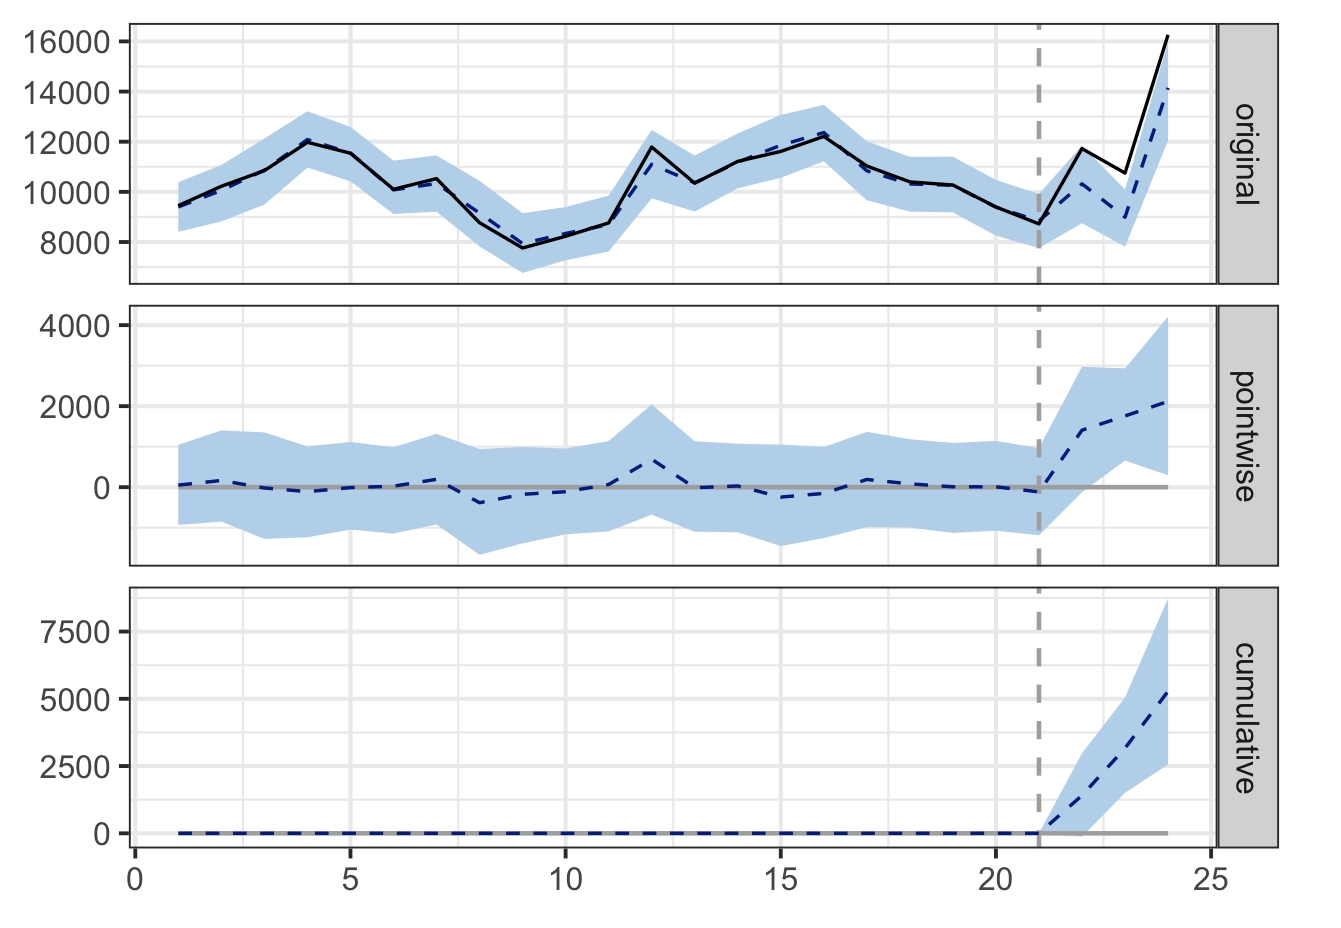

## Observation

In the given scenario, actual revenue after treatment was 12,913, compared to a baseline of 10,760.

The BSTS Synthetic Control model estimated the treatment effect as 1,761 (a 16% increase), while the true effect was 2,152 (a 20% increase). This means that the model underestimated the true effect by assigning a higher value to the predicted baseline than was accurate.

This means that the BSTS model had better performance than the Difference-in-Differences model, but worse performance than the Synthetic Control with Lasso model or the Event Study model.

Remember that these findings are specific to this particular dataset; results will vary with different datasets.